In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020.csv


In [ ]:
import pandas as pd

df = pd.read_csv("ai4i2020.csv")
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [ ]:
# Step 2: Data Preprocessing

from sklearn.preprocessing import LabelEncoder

# convert categorical to numeric
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# remove unnecessary columns
df = df.drop(['UDI', 'Product ID'], axis=1)

# check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [ ]:
# Step 3: Feature Selection

# features (input)
X = df.drop('Machine failure', axis=1)

# target (output)
y = df['Machine failure']

print("Features:")
print(X.head())

print("Target:")
print(y.head())

Features:
   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     2                298.1                    308.6                    1551   
1     1                298.2                    308.7                    1408   
2     1                298.1                    308.5                    1498   
3     1                298.2                    308.6                    1433   
4     1                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  TWF  HDF  PWF  OSF  RNF  
0         42.8                0    0    0    0    0    0  
1         46.3                3    0    0    0    0    0  
2         49.4                5    0    0    0    0    0  
3         39.5                7    0    0    0    0    0  
4         40.0                9    0    0    0    0    0  
Target:
0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64


In [ ]:
# Predictions 
 y_pred = best_model.predict(X_test)
 y_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
# Prediction
y_pred = model.predict(X_test)

# Metrics
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

In [ ]:
#Metrics 
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report (Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Load dataset
df = pd.read_csv("ai4i2020.csv")

# Step 2: Encode Type column
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# Step 3: Remove unwanted columns
df = df.drop(['UDI', 'Product ID'], axis=1)

# Step 4: Feature and target
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

# IMPORTANT FIX: convert to numpy
X = X.values
y = y.values

# Step 5: Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Model training
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

print("Model training completed")

# Step 7: Prediction
y_pred = model.predict(X_test)

# Step 8: Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Step 9: Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Step 10: Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model training completed
Accuracy: 0.999
Confusion Matrix:
[[1939    0]
 [   2   59]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
# Confusion Matrix cm = confusion_matrix(y_test, y_pred) 
 plt.figure(figsize=(6,4)) 
 sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
 plt.xlabel("Predicted") 
 plt.ylabel("Actual")
 plt.title("Confusion Matrix") plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1939    0]
 [   2   59]]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

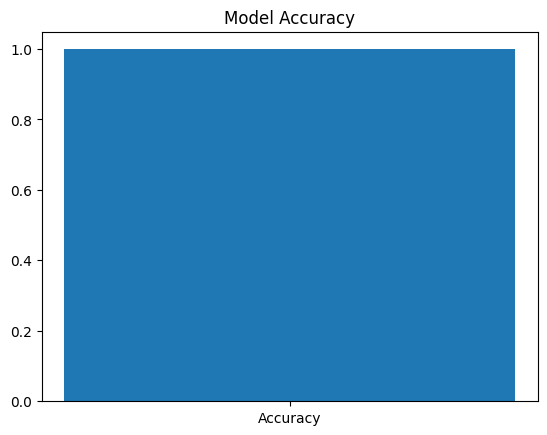

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

plt.bar(['Accuracy'], [accuracy])
plt.title("Model Accuracy")
plt.show()

In [ ]:
#ROC Curve Code (Graph)
  from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# ROC-AUC score
roc_score = roc_auc_score(y_test, y_pred)

# Plot graph
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_score)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")c


plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()